# MAUDE Adverse Event Analysis: Cochlear Implant Devices
## Project Summary
Analysis of FDA MAUDE adverse event reports for cochlear implant devices using Python (pandas, matplotlib)

## Data Source
FDA MAUDE database export, downloaded June 2026.
Device category: cochlear implants (Product Code PGQ)
Raw file: 73 rows, 15 columns

## Data Quality Issues Found and Fixed
- Rows 66 to 72 contained FDA disclaimer footer text captured as data rows.
Removed with iloc[:66].
- Tow columns were empty and dropped: Unnamed: 0 and Exemption Number.
- Event Date column had 22 unparseable values (30% of records) converted to NaT. These rows are excluded from year based analysis.
- File was exported as .xls binary format despite .csv extension. Loaded with read_excel().

## Known limitations
Year based analysis covers only 44 of 66 records due to missing date.

## Findings
56 of 66 records (85%) were classified as injuries. However, injury severity is not captured in this dataset. High injury report volume may reflect mandatory reporting compliance rather than device safety concerns. Further analysis would require severity grading and report rate normalization by units sold.

Cochlear Ltd accounts for 60 of 66 records (91%) vs MED-EL at 6 (9%). This difference cannot be interpreted as a safety signal without normalizing by market share and units sold. Differences in reporting culture and vigilance team capacity may also contribute.

Migration and circuit failure are the most clinically significant failure modes in this dataset. Migration is generally attributed to surgical technique and biological fixation rather than instrument handling. Impedance and circuit failure could theoretically result from electrode damage during handling, however this risk is considered low when surgical instruments meet Class Ir design requirements under EU MDR, including controlled tip geometry and verified gripping force.

Device rejection, while appearing only once in this dataset, represents a potentially severe outcome requiring explantation. Under ISO 14971 risk evaluation, low probability events with catastrophic severity remain significant risk drivers and warrant monitoring in post market surveillance regardless of absolute report count.

Infection related patient problems (unspecified infection, abscess, inflammation) combined with implant failure account for 7 records. For permanently implanted devices, these outcomes carry explantation risk, representing the most clinically significant finding in this dataset. Severity justifies close monitoring regardless of low absolute report counts under ISO 14971 risk principles.

In [ ]:
#Cell 1: Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Cell 2:Mount Google Drive
#Connect to google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Cell 3:Load CSV
# Load raw data
df= pd.read_excel('/content/drive/MyDrive/Colab Notebooks/maudeExcelReport5.csv')
print(df.shape)
print(df.head())

(73, 15)
  Unnamed: 0                                        Web Address  \
0        NaN  https://www.accessdata.fda.gov/scripts/cdrh/cf...   
1        NaN  https://www.accessdata.fda.gov/scripts/cdrh/cf...   
2        NaN  https://www.accessdata.fda.gov/scripts/cdrh/cf...   
3        NaN  https://www.accessdata.fda.gov/scripts/cdrh/cf...   
4        NaN  https://www.accessdata.fda.gov/scripts/cdrh/cf...   

        Report Number           Event Date   Event Type  \
0  9710014-2026-00463  2026-05-07 04:00:00  Malfunction   
1  6000034-2026-01607  2026-02-26 05:00:00       Injury   
2  6000034-2026-01606  2026-02-26 05:00:00       Injury   
3  6000034-2026-00904  2026-01-30 05:00:00       Injury   
4  6000034-2026-00905  2026-01-30 05:00:00       Injury   

                              Manufacturer        Date Received Product Code  \
0  MED-EL ELEKTROMEDIZINISCHE GERAETE GMBH  2026-05-21 04:00:00          PGQ   
1                             COCHLEAR LTD  2026-05-05 04:00:00          

In [ ]:
#Cell 4:Remove footer rows
#Remove FDEA disclaimer footer rows that were captured as data
df = df.iloc[:66]
print(df.shape)

(66, 15)


In [ ]:
#Cell 5:Drop empty columns
#Drop empty colums with no useful data
df= df.drop(columns=['Unnamed: 0','Exemption Number'])
print(df.shape)

(66, 13)


In [ ]:
#Cell 6:Fix date column and extract year
# Convert Event Date to proper date format and extract year
df['Event Date']= pd.to_datetime(df['Event Date'], errors='coerce')
df['Year']= df['Event Date'].dt.year
print(df['Year'].value_counts().sort_index())

Year
2023.0    15
2024.0    13
2025.0    18
2026.0     5
Name: count, dtype: int64


In [ ]:
#Cell 7:Data quality Check
## Check remaining missing values after cleaning
print(df.isnull().sum())

Web Address          0
Report Number        0
Event Date          15
Event Type           0
Manufacturer         0
Date Received        0
Product Code         0
 Brand Name          0
 Device Problem      0
Patient Problem      1
PMA/PMN Number      29
Number of Events     0
Event Text           0
Year                15
dtype: int64


In [ ]:
#Cell 8:Fix inconsistent manufacturer naming, same company submitted under two name variants
df['Manufacturer']=df['Manufacturer'].replace('COCHLEAR LIMITED', 'COCHLEAR LTD')
print(df['Manufacturer'].value_counts())

Manufacturer
COCHLEAR LTD                               60
MED-EL ELEKTROMEDIZINISCHE GERAETE GMBH     6
Name: count, dtype: int64


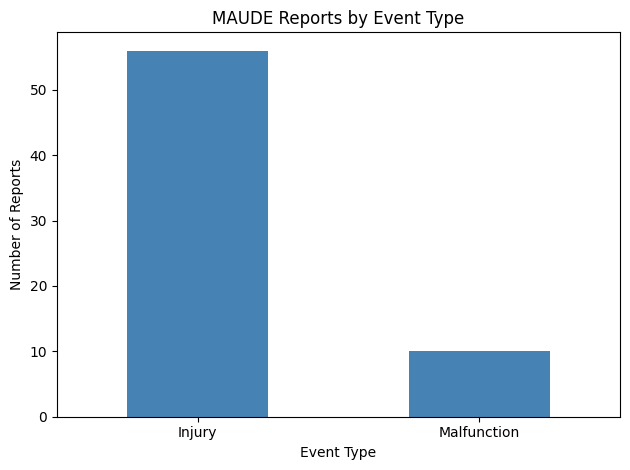

In [ ]:
#Cell 9:Event Type chart
#Chart 1: Reports by Event Type
df['Event Type'].value_counts().plot(kind='bar', color='steelblue')
plt.title('MAUDE Reports by Event Type')
plt.xlabel('Event Type')
plt.ylabel('Number of Reports')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


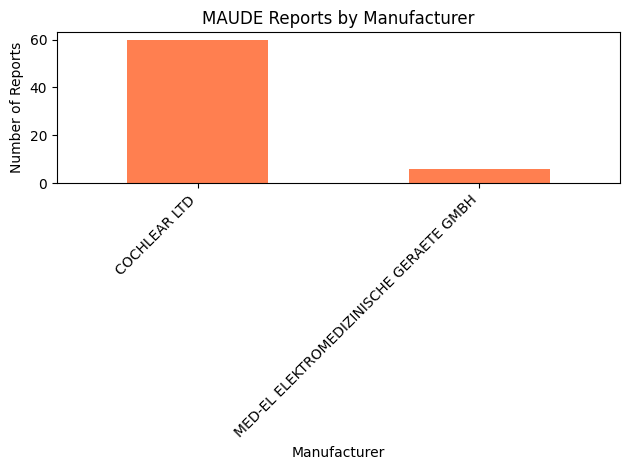

In [ ]:
# Cell 10: Chart 2: Reports by Manufacturer

df['Manufacturer'].value_counts().plot(kind='bar', color='coral')
plt.title('MAUDE Reports by Manufacturer')
plt.xlabel('Manufacturer')
plt.ylabel('Number of Reports')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
# Cell 10: Chart 2: Reports by Manufacturer

print(df[' Device Problem'].value_counts())
device_problems = df[' Device Problem'].dropna()
device_problems = device_problems.str.split(';')
device_problems = device_problems.explode()
device_problems = device_problems.str.strip()
print(device_problems.value_counts())



 Device Problem
Appropriate Term/Code Not Available                                                         16
Therapeutic or Diagnostic Output Failure                                                    11
Output Problem                                                                               9
Insufficient Information                                                                     5
Adverse Event Without Identified Device or Use Problem                                       3
Migration                                                                                    2
Impedance Problem                                                                            2
Unexpected Therapeutic Results; Therapeutic or Diagnostic Output Failure; Noise, Audible     2
Circuit Failure; Migration                                                                   2
Circuit Failure; No Apparent Adverse Event; Migration                                        2
Circuit Failure; Impedance Problem

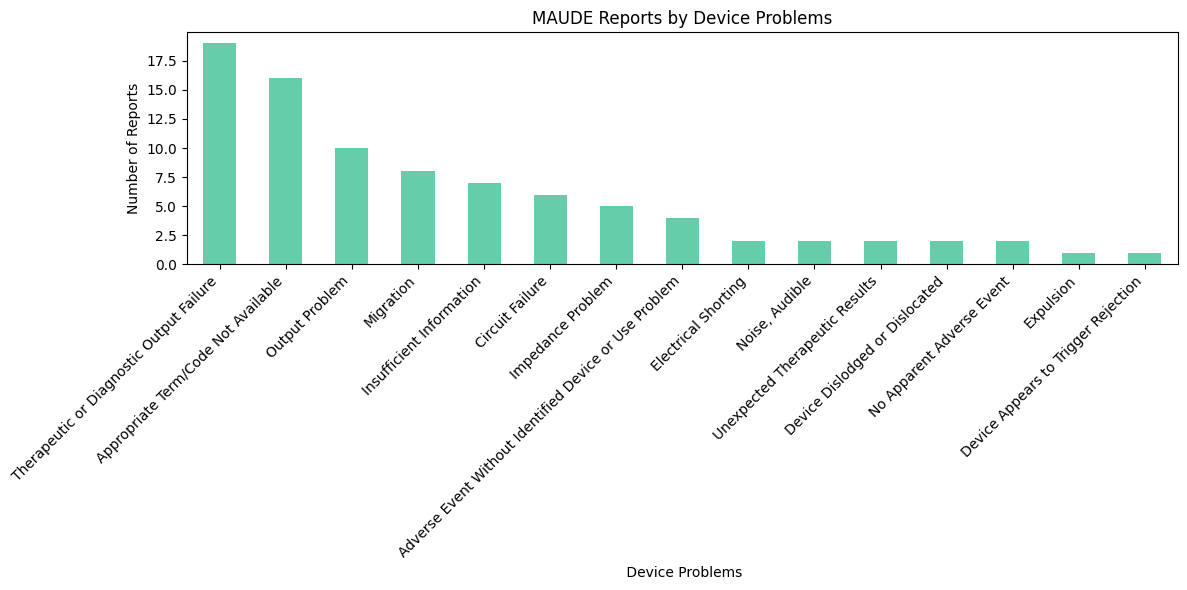

In [ ]:
#Cell 11: Chart 3: Device Problem frequency, splitting combination codes

device_problems.value_counts().plot(kind='bar', figsize=(12,6), color='mediumaquamarine')


plt.title('MAUDE Reports by Device Problems')
plt.xlabel(' Device Problems')
plt.ylabel('Number of Reports')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()


plt.show()


In [ ]:
# Cell 12: Explore Patient Problem column before splitting

print(df['Patient Problem'].value_counts())

Patient Problem
Appropriate Clinical Signs, Symptoms, Conditions Term / Code Not Available                                               36
No Clinical Signs, Symptoms or Conditions                                                                                 7
Insufficient Information                                                                                                  5
Pain                                                                                                                      3
Unspecified Infection                                                                                                     3
Undesired Nerve Stimulation; Pain                                                                                         2
Appropriate Clinical Signs, Symptoms, Conditions Term / Code Not Available; No Clinical Signs, Symptoms or Conditions     2
Failure of Implant; No Clinical Signs, Symptoms or Conditions                                                       

In [ ]:
# Cell 13: Split and explode Patient Problem combination codes

patient_problem = df['Patient Problem'].dropna()
patient_problem = patient_problem.str.split(';')
patient_problem = patient_problem.explode()
patient_problem = patient_problem.str.strip()
print(patient_problem.value_counts())

Patient Problem
Appropriate Clinical Signs, Symptoms, Conditions Term / Code Not Available    38
No Clinical Signs, Symptoms or Conditions                                     12
Pain                                                                           6
Insufficient Information                                                       6
Unspecified Infection                                                          3
Undesired Nerve Stimulation                                                    2
Failure of Implant                                                             2
Tinnitus                                                                       2
Abscess                                                                        1
Inflammation                                                                   1
Name: count, dtype: int64


In [ ]:
#Filter out reporting limitation entries
exclusions = ['Appropriate Clinical Signs, Symptoms, Conditions Term / Code Not Available', 'Insufficient Information']

patient_problem_filtered = patient_problem[~patient_problem.isin(exclusions)]

print(patient_problem_filtered.value_counts())

Patient Problem
No Clinical Signs, Symptoms or Conditions    12
Pain                                          6
Unspecified Infection                         3
Undesired Nerve Stimulation                   2
Failure of Implant                            2
Tinnitus                                      2
Abscess                                       1
Inflammation                                  1
Name: count, dtype: int64


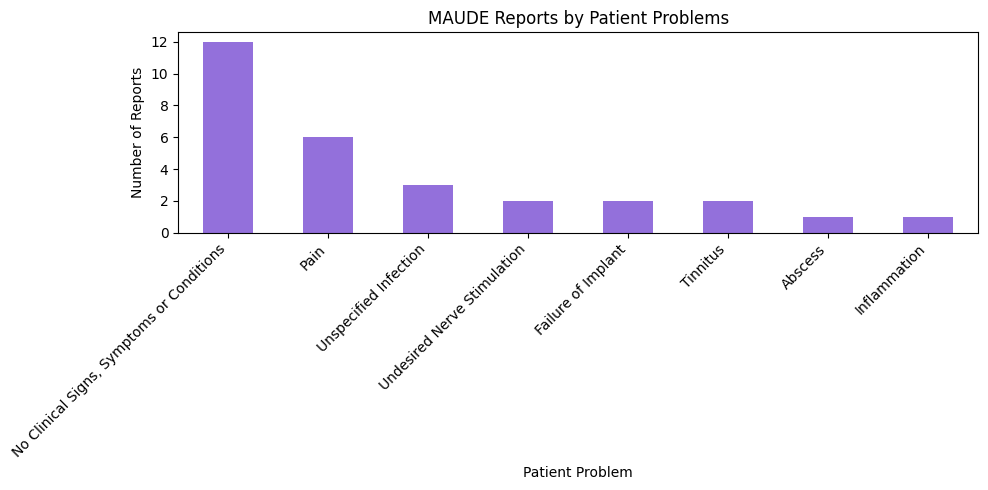

In [ ]:
patient_problem_filtered.value_counts().plot(kind='bar', figsize=(10,5), color='mediumpurple')


plt.title('MAUDE Reports by Patient Problems')
plt.xlabel('Patient Problem')
plt.ylabel('Number of Reports')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()


plt.show()


## Conclusion

This analysis explored 66 FDA MAUDE adverse event reports for cochlear implant devices covering the period 2023 to 2026.

**Manufacturer distribution:** Cochlear Ltd accounts for 91% of reports versus MED-EL at 9%. This difference cannot be interpreted as a safety signal. Report volume reflects market share and reporting culture differences as much as device performance, and no conclusions on comparative safety can be drawn without normalization by units sold.

**Device problems:** Output failure is the dominant technical failure mode across the dataset. Migration appears frequently as a secondary finding, however causation is multifactorial, involving surgical technique, patient anatomy, and biological response, and is outside the scope of this analysis to interpret further.

**Patient outcomes:** Pain is the most frequently reported patient problem but cannot be meaningfully interpreted without severity grading and temporal context. It is not possible to determine from this dataset whether reported pain is acute postoperative pain, chronic, or related to an underlying condition. Implant failure, while low frequency at 2 records, represents the most serious patient consequence in this dataset. A patient who has undergone a major surgical procedure with significant inherent risk, and whose implant subsequently fails, faces revision surgery with compounded risk and no benefit yet received. This outcome warrants close monitoring regardless of its low absolute count, consistent with ISO 14971 severity based risk principles.